In [1]:
import matplotlib.pyplot as plt
import monai
import numpy as np
import torch
from preprocessing.utils import img_path, natural_key
import pandas as pd
from sklearn.model_selection import train_test_split
import tempfile
import os

Field "model_server_url" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'


In [2]:
# Data Preparation
data_path = os.sep.join([".","padding_median_50"])
directory_names = os.listdir(data_path)
directory_path = sorted(directory_names, key=natural_key)
image_name = "/image.nii.gz"
comp_image_file = [s + image_name for s in directory_path]
images = [os.sep.join([data_path, f]) for f in comp_image_file]

# Read the CSV file --> Labels
labels_csv = pd.read_csv("./Lipo.csv")
labels_csv.replace(-1, 1, inplace=True)
labels = labels_csv['Diagnosis_binary'].to_numpy()
# Ensure the length of images and labels match
assert len(images) == len(labels), "Number of images and labels must match."
all_files = [{"image": img, "label": lbl} for img, lbl in zip(images, labels)]
del data_path, directory_names, directory_path, comp_image_file, labels_csv, images, labels, image_name

In [3]:
# Split the data into training and test sets
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)
# Print some information to check the split
print(f"Number of training images: {len(train_files)}")
print(f"Number of test images: {len(val_files)}")
del val_files

Number of training images: 92
Number of test images: 23


In [4]:
del all_files

In [5]:
# Create DenseNet121, CrossEntropyLoss and Adam optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load("./model_fold_4_20240712.pth")
model.eval()

DenseModel(
  (features): Sequential(
    (conv0): Conv3d(1, 64, kernel_size=(5, 5, 5), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
    (norm0): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (relu0): ReLU()
    (pool0): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (layers): Sequential(
          (norm1): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (relu1): ReLU()
          (conv1): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
          (norm2): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (relu2): ReLU()
          (conv2): Conv3d(64, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (dropout): Dropout(p=0.3, inplace=False)
        )
      )
      (denselayer2): _DenseLayer(
     

In [6]:
from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,
    RandRotate,
    RandZoom,
    RandScaleIntensity,
    RandAdjustContrast,
    RandFlip,
    RandRicianNoise,
    RandGaussianSmooth,
    Resize,
    EnsureChannelFirstd,
    Compose,
    LoadImaged,
    RandFlipd,
    RandRotated,
    RandZoomd,
    Resized,
    ScaleIntensityRanged,
    EnsureTyped,
)

# Global variables
testing_probability = 0.2

def CreateTrainTransform():
    """
    :return: A preprocessing pipeline for the training samples.
    """

    train_transforms = Compose(
        [
            LoadImaged(
                # image_only=True
                #keys='image'
                "image"
                ),

            EnsureChannelFirstd(
                'image'
                ),

            # ---------- Spatial augmentations ----------

            # - RandFilpd prob = 0.5
            RandFlipd(
                'image',
                prob=0.5,
                spatial_axis=0),

            # - RandRotated prob = 0.2
            RandRotated(
                'image',
                range_z=0.2,
                prob=0.2),

            # - RandZoomd prob = 0.2
            RandZoomd(
                'image',
                prob=testing_probability,
                min_zoom=0.7,
                max_zoom=1.3),

            # ---------- Intensity augmentations ----------

            # - RandScaleIntensityd prop 0.15
            #RandScaleIntensity(
                #keys='image',
            #    prob=0.15,
            #    factors=(-0.3, 0.3)),

            # - RandAdjustContrastd = 0.15
            #RandAdjustContrast(
                #keys='image',
            #    prob=0.15,
            #    gamma=(0.65, 1.5)),

            # - RandomRicianNoised = 0.15
            #RandRicianNoise(
                #keys='image',
            #    prob=0.15,
            #    mean=1,
            #    std=0.5),

            # - RandGaussianSmoothd = 0.2
            #RandGaussianSmooth(
                #keys='image',
            #    prob=0.2
            #),
        ]
    )
    return train_transforms

In [7]:
from monai.visualize import SmoothGrad
train_transforms = CreateTrainTransform()
# train_ds = monai.data.ArrayDataset(X_train, labels=y_train, img_transform=train_transforms)

occ_sens = monai.visualize.OcclusionSensitivity(nn_module=model, mask_size=12, n_batch=1)

directory = os.environ.get("MONAI_DATA_DIRECTORY")
root_dir = tempfile.mkdtemp() if directory is None else os.path.expanduser(directory)
persistent_cache = os.path.join(root_dir, "persistent_cache")
train_ds = monai.data.PersistentDataset(data=train_files, transform=train_transforms, cache_dir=persistent_cache)

the_slice = train_ds[0]["image"].shape[-1] // 2
occ_sens_b_box = [-1, -1, -1, -1, the_slice - 1, the_slice]
# Create an instance of SmoothGrad
smooth_grad = SmoothGrad(model, stdev_spread=0.15, n_samples=25, magnitude=True, verbose=True)


In [8]:
del directory, testing_probability, train_files

Which slice is it showing? 25
5


Computing SmoothGrad:   4%|▍         | 1/25 [00:16<06:42, 16.75s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 96.00 MiB. GPU 0 has a total capacty of 4.00 GiB of which 0 bytes is free. Of the allocated memory 10.37 GiB is allocated by PyTorch, and 371.21 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

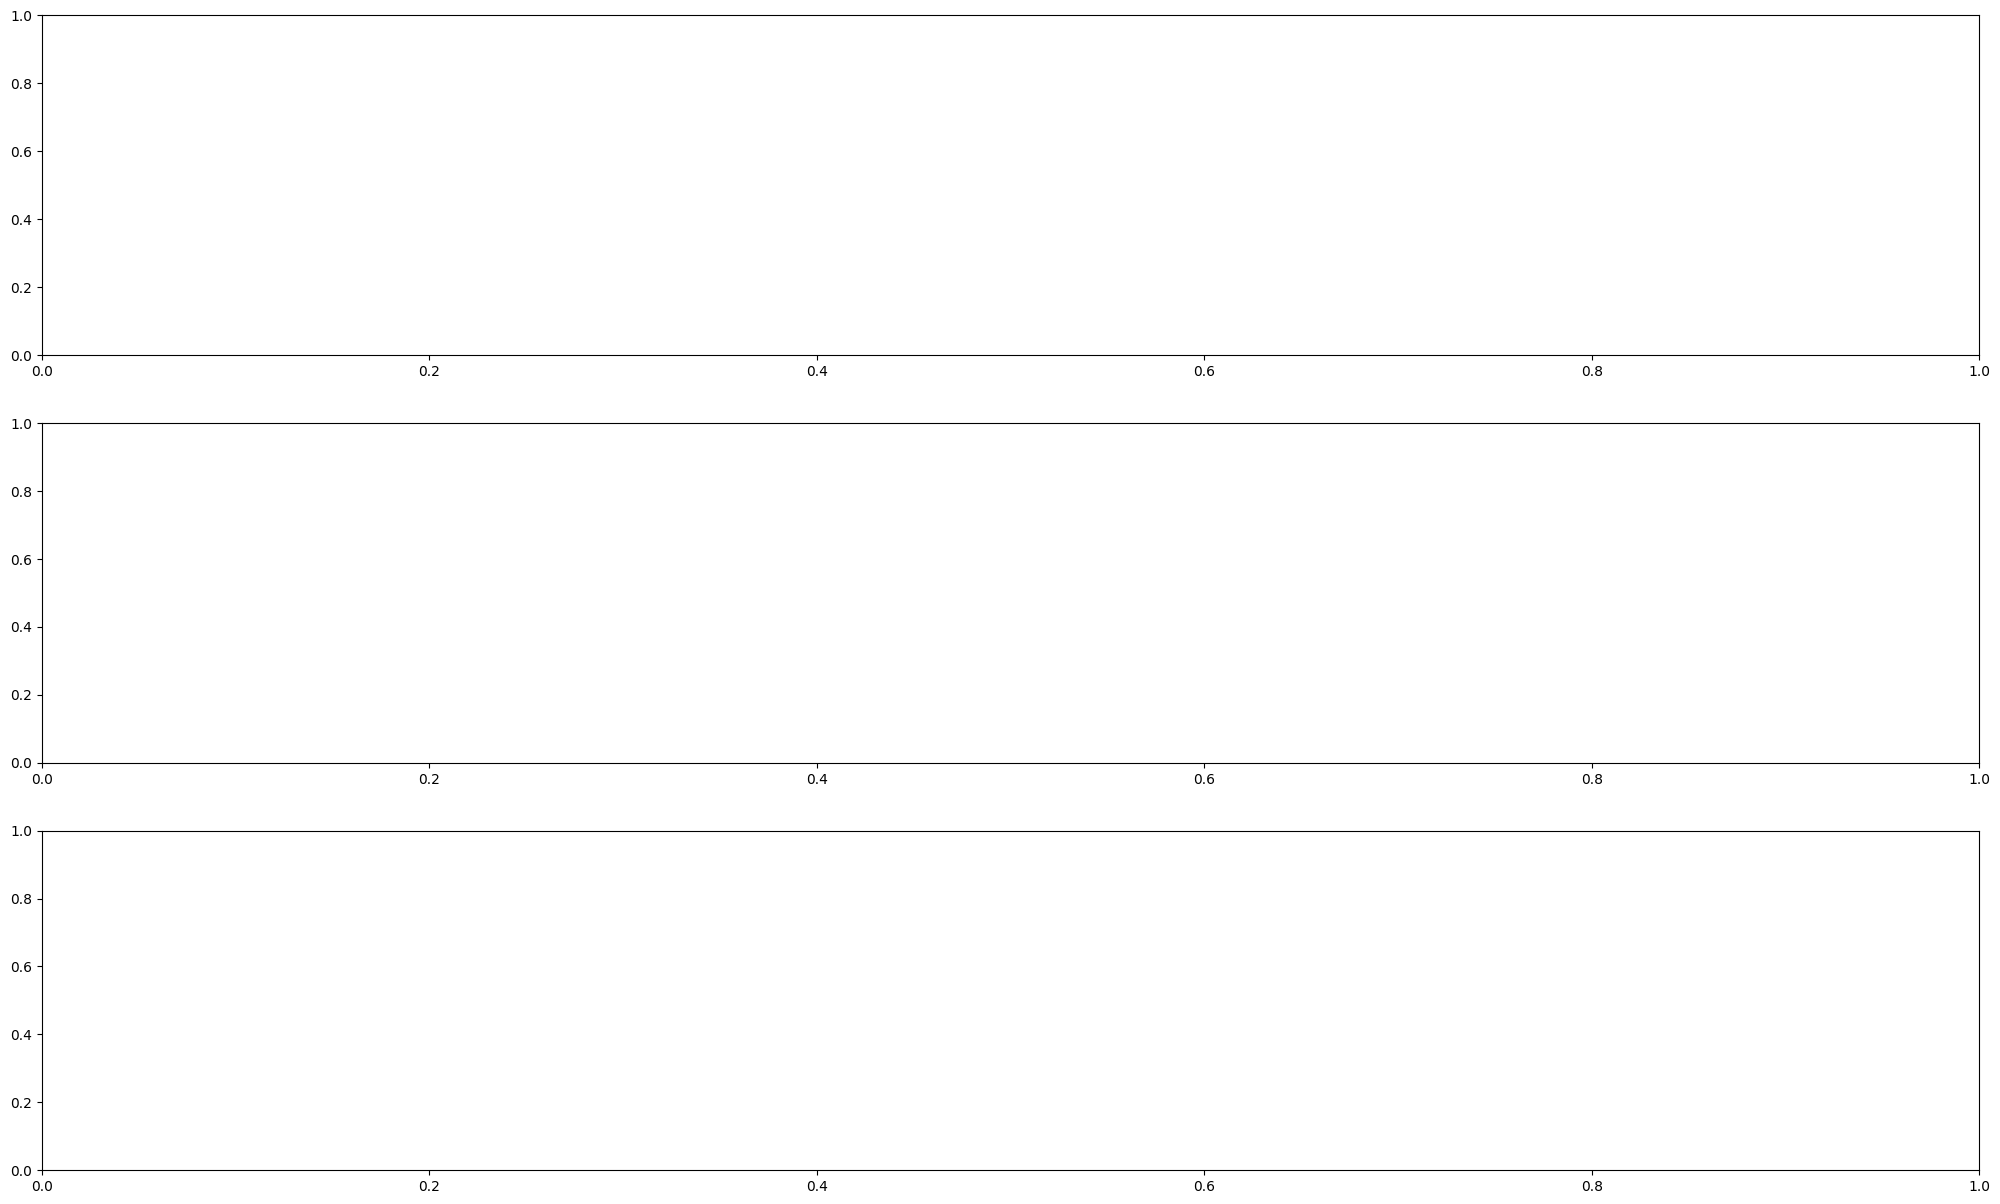

In [9]:
train_transforms.set_random_state(42)
n_examples = 1
subplot_shape = [3, n_examples]
fig, axes = plt.subplots(*subplot_shape, figsize=(25, 15), facecolor="white")
items = np.random.choice(len(train_ds), size=len(train_ds), replace=False)
print("Which slice is it showing?", the_slice)

example = 0
for item in items:
    data = train_ds[item]  # this fetches training data with random augmentations
    image = data["image"].to(device).unsqueeze(0)
    label = data["label"]
    y_pred = model(image)
    pred_label = y_pred.argmax(1).item()
    # Only display tumours images
    if label != 1 or label != pred_label:
        continue
    else:
        print(item)

    img = image.detach().cpu().numpy()[..., the_slice]

    name = "actual: "
    name += "lesion" if label == 1 else "non-lesion"
    name += "\npred: "
    name += "lesion" if pred_label == 1 else "non-lesion"
    name += f"\nlesion: {y_pred[0,1]:.3}"
    name += f"\nnon-lesion: {y_pred[0,0]:.3}"

    # run smoothgrad
    cam_result = smooth_grad(x=image, index=None)
    cam_result = cam_result[..., the_slice]

    # run occlusion
    occ_result, _ = occ_sens(x=image, b_box=occ_sens_b_box)
    occ_result = occ_result[0, pred_label][None, None, ..., -1]

    for row, (im, title) in enumerate(
        zip(
            [img, cam_result, occ_result],
            [name, "CAM", "Occ. sens."],
        )
    ):
        cmap = "gray" if row == 0 else "jet"
        ax = axes[row, example]
        if isinstance(im, torch.Tensor):
            im = im.cpu().detach()
        im_show = ax.imshow(im[0][0], cmap=cmap)

        ax.set_title(title, fontsize=25)
        ax.axis("off")
        fig.colorbar(im_show, ax=ax)

    example += 1
    if example == n_examples:
        break